Kolom: Index(['Provinsi', 'Tahun', 'Produksi', 'Luas Panen', 'Curah hujan',
       'Kelembapan', 'Suhu rata-rata'],
      dtype='str')
  Provinsi  Tahun   Produksi  Luas Panen  Curah hujan  Kelembapan  \
0     Aceh   1993  1329536.0    323589.0       1627.0       82.00   
1     Aceh   1994  1299699.0    329041.0       1521.0       82.12   
2     Aceh   1995  1382905.0    339253.0       1476.0       82.72   
3     Aceh   1996  1419128.0    348223.0       1557.0       83.00   
4     Aceh   1997  1368074.0    337561.0       1339.0       82.46   

   Suhu rata-rata  
0           26.06  
1           26.92  
2           26.27  
3           26.08  
4           26.31  
<class 'pandas.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provinsi        224 non-null    str    
 1   Tahun           224 non-null    int64  
 2   Produksi        224 non-null    float64
 3   Luas Pa

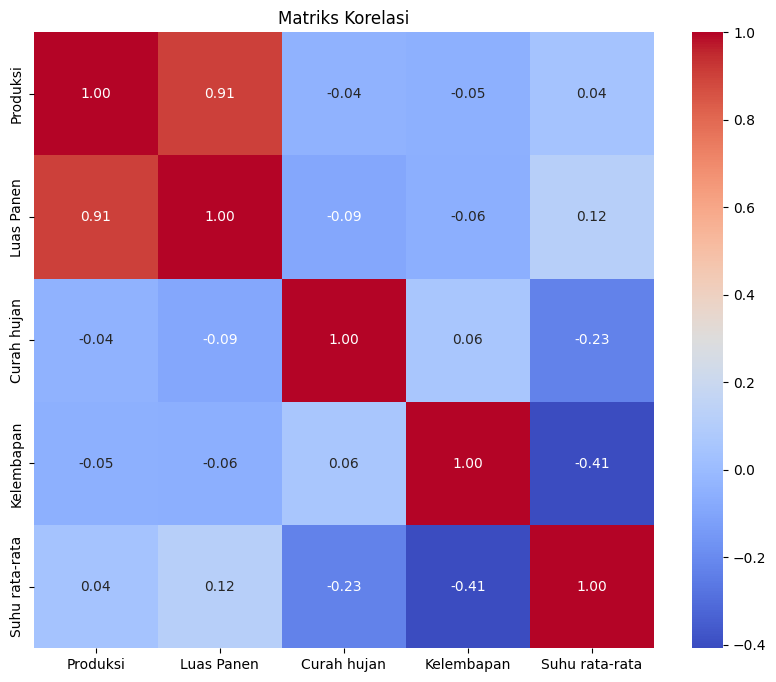

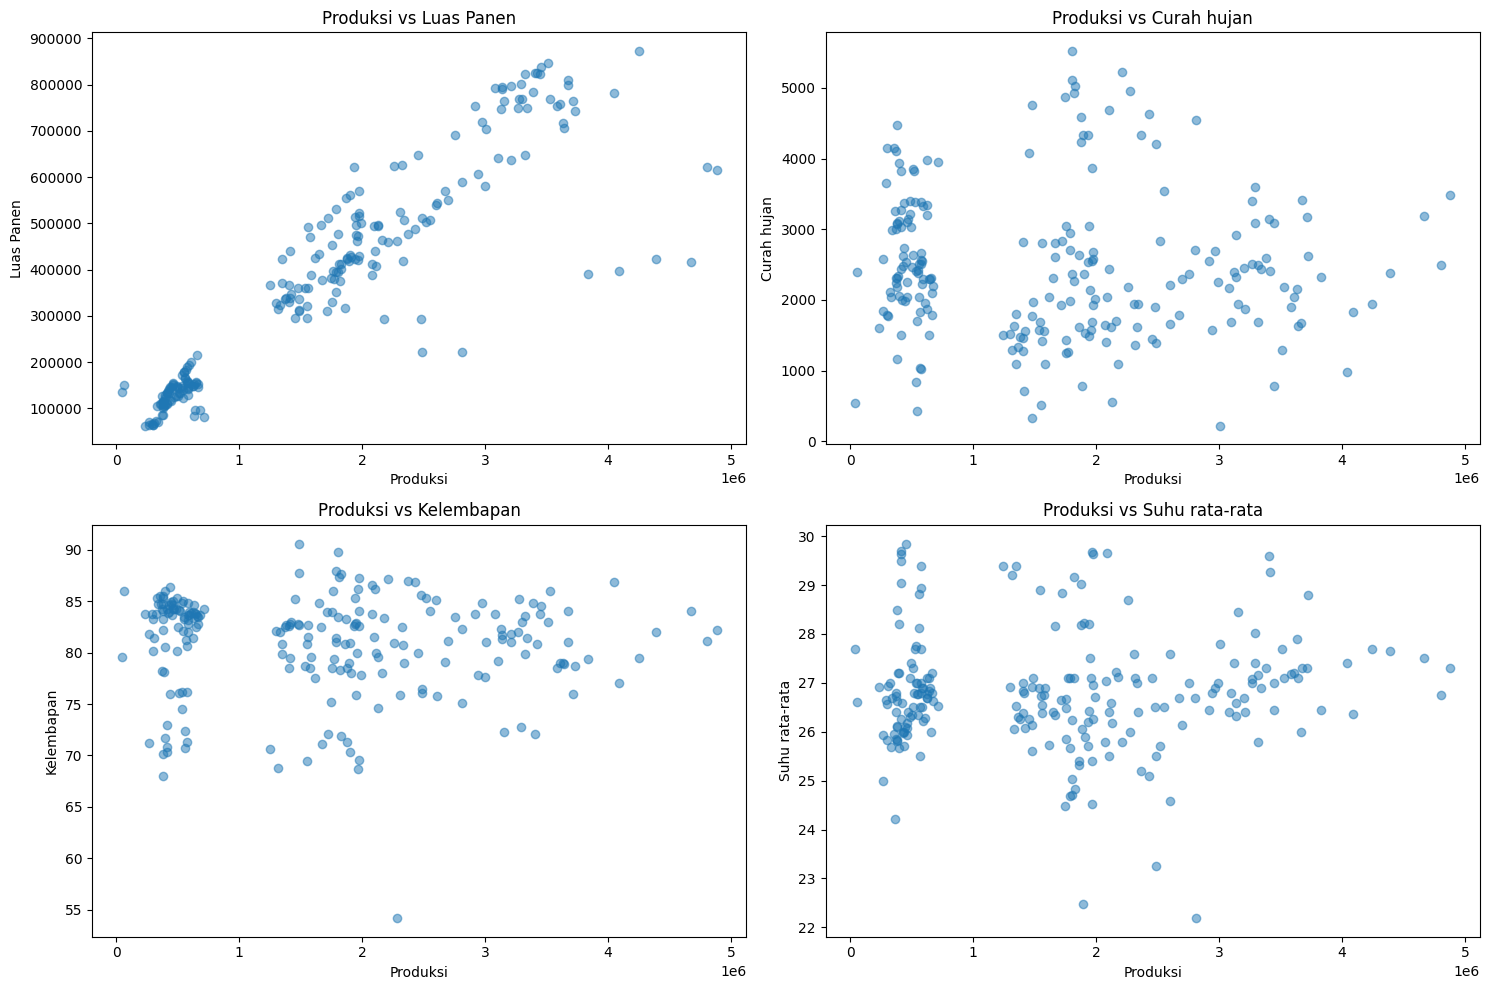


[Model Regresi Linear]
Mean Squared Error: 0.0049163188153713705
R-squared: 0.8698382149351498

[Model ARIMA]
Mean Squared Error (MSE): 14362605334323.615


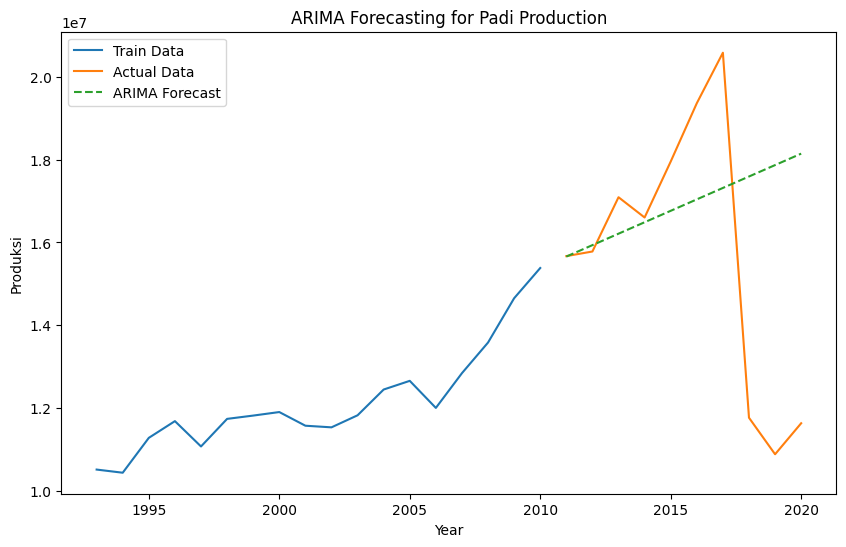

In [4]:
# Import Library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA

# 1. Load dataset
file_path = 'Data_Tanaman_Padi_Sumatera.csv'
data = pd.read_csv(file_path)

# Menampilkan informasi dasar
print("Kolom:", data.columns)
print(data.head())
print(data.info())
print(data.describe())

# 2. Data Cleaning & Preprocessing
# Memperbaiki typo 'Provinst' menjadi 'Provinsi' dari hasil OCR
# Mengabaikan kolom non-numerik untuk korelasi
columns_to_drop = ['Provinsi', 'Tahun']
numeric_data = data.drop(columns=columns_to_drop)

# Korelasi (Heatmap)
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi")
plt.show()

# 3. Visualisasi Scatter Plots (Perbaikan nama kolom dan tanda kutip)
features = ['Luas Panen', 'Curah hujan', 'Kelembapan', 'Suhu rata-rata']
plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    plt.scatter(data['Produksi'], data[col], alpha=0.5)
    plt.xlabel("Produksi")
    plt.ylabel(col)
    plt.title(f"Produksi vs {col}")

plt.tight_layout()
plt.show()

# 4. Handling Missing Values
imputer = SimpleImputer(strategy='mean')
cols_to_impute = ['Produksi', 'Luas Panen', 'Curah hujan', 'Kelembapan', 'Suhu rata-rata']
numeric_data[cols_to_impute] = imputer.fit_transform(numeric_data[cols_to_impute])

# 5. Normalisasi Data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(numeric_data)
normalized_data = pd.DataFrame(scaled_data, columns=numeric_data.columns)

# 6. Model 1: Regresi Linear
X = normalized_data.drop('Produksi', axis=1)
y = normalized_data['Produksi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

# Evaluasi Regresi Linear
mse_lr = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)
print(f'\n[Model Regresi Linear]')
print(f'Mean Squared Error: {mse_lr}')
print(f'R-squared: {r2_lr}')

# 7. Model 2: ARIMA Forecasting
# Agregasi produksi per tahun
time_series_data = data.groupby('Tahun')['Produksi'].sum().reset_index()

# Split data (Contoh: 10 tahun terakhir untuk test)
train_ts = time_series_data[:-10]
test_ts = time_series_data[-10:]

# Membangun model ARIMA (p,d,q = 1,1,1)
model_arima = ARIMA(train_ts['Produksi'], order=(1, 1, 1))
arima_result = model_arima.fit()

# Forecasting
forecast_values = arima_result.get_forecast(steps=len(test_ts))
forecast_mean = forecast_values.predicted_mean

# Evaluasi ARIMA
mse_arima = mean_squared_error(test_ts['Produksi'], forecast_mean)
print(f'\n[Model ARIMA]')
print(f'Mean Squared Error (MSE): {mse_arima}')

# Visualisasi Forecasting
plt.figure(figsize=(10, 6))
plt.plot(train_ts['Tahun'], train_ts['Produksi'], label='Train Data')
plt.plot(test_ts['Tahun'], test_ts['Produksi'], label='Actual Data')
plt.plot(test_ts['Tahun'], forecast_mean, label='ARIMA Forecast', linestyle='--')
plt.title('ARIMA Forecasting for Padi Production')
plt.xlabel('Year')
plt.ylabel('Produksi')
plt.legend()
plt.show()